# 02 - Exploratory Data Analysis: Food Delivery & Demand

In [1]:
# 1. Imports and setup for food delivery analysis
# We analyze food demand patterns, price discounts, and delivery logistics delays (traffic, weather).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Delivery EDA environment initialized.")


Delivery EDA environment initialized.


In [2]:
# 2. Ingest food demand training dataset with center and meal metadata
# We merge the demand orders table with fulfillment center info and meal info on their respective keys.
train = pd.read_csv("../data/raw/delivery/food_demand_train.csv")
centers = pd.read_csv("../data/raw/delivery/fulfilment_center_info.csv")
meals = pd.read_csv("../data/raw/delivery/meal_info.csv")

print(f"Demand records: {len(train):,}")
print(f"Fulfillment centers: {len(centers):,}")
print(f"Meal items: {len(meals):,}")

# Merge into unified demand dataframe
df_demand = train.merge(centers, on="center_id", how="left").merge(meals, on="meal_id", how="left")
df_demand.head()


Demand records: 456,548
Fulfillment centers: 77
Meal items: 51


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.00,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.00,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.00,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.00,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.00,Beverages,Indian


In [3]:
# 3. Check for missing values and duplicates
# Ensure merged demand data is clean and consistent across center-meal-week tuples.
print("Missing values in merged demand data:")
print(df_demand.isnull().sum())

dupes = df_demand.duplicated(subset=["week", "center_id", "meal_id"]).sum()
print(f"\nDuplicate (week, center_id, meal_id) combinations: {dupes}")


Missing values in merged demand data:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

Duplicate (week, center_id, meal_id) combinations: 0


,base_price,checkout_price,discount_amount,discount_pct,num_orders
count,456548.00,456548.00,456548.00,456548.00,456548.00
mean,354.16,332.24,21.92,5.90,261.87
std,160.72,152.94,48.50,11.23,395.92
min,55.35,2.97,-185.30,0.00,13.00
25%,243.50,228.95,-1.00,0.00,54.00
50%,310.46,296.82,1.00,0.14,136.00
75%,458.87,445.23,16.52,6.24,324.00
max,866.27,866.27,561.60,99.06,24299.00


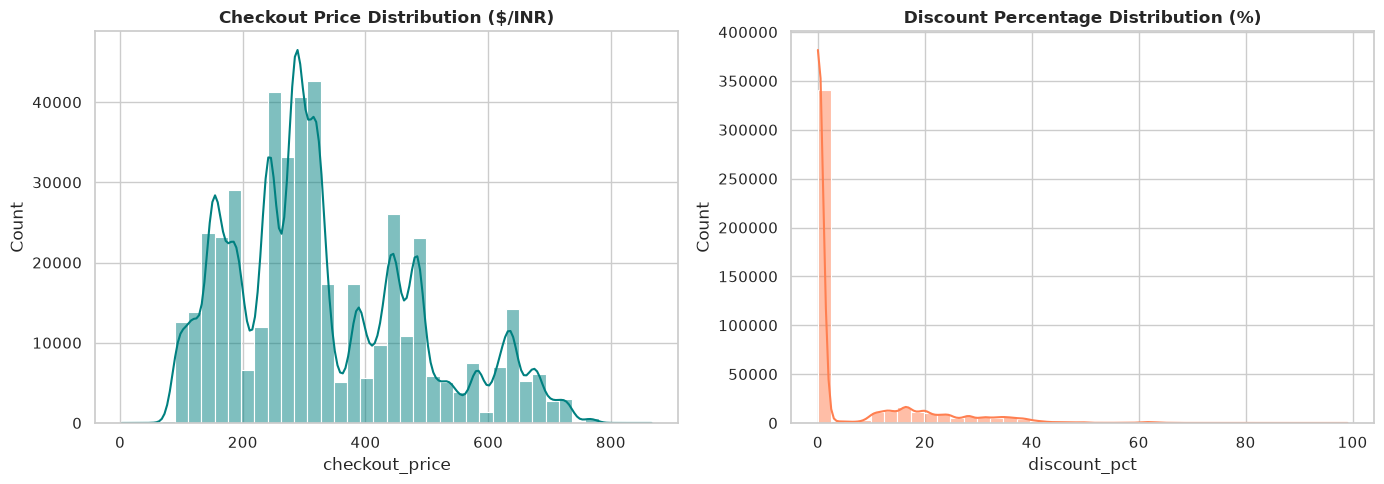

In [4]:
# 4. Calculate discount amounts and discount percentages
# Discount = base_price - checkout_price. A higher discount typically drives higher demand velocity.
df_demand["discount_amount"] = df_demand["base_price"] - df_demand["checkout_price"]
df_demand["discount_pct"] = (df_demand["discount_amount"] / df_demand["base_price"] * 100).clip(lower=0)

display(df_demand[["base_price", "checkout_price", "discount_amount", "discount_pct", "num_orders"]].describe())

# Visualize checkout price and discount distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_demand["checkout_price"], bins=40, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Checkout Price Distribution ($/INR)", fontsize=12, fontweight="bold")

sns.histplot(df_demand["discount_pct"], bins=40, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Discount Percentage Distribution (%)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


/tmp/ipykernel_26313/2623700330.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_summary, x="promo_type", y="avg_orders", palette="Blues_d")


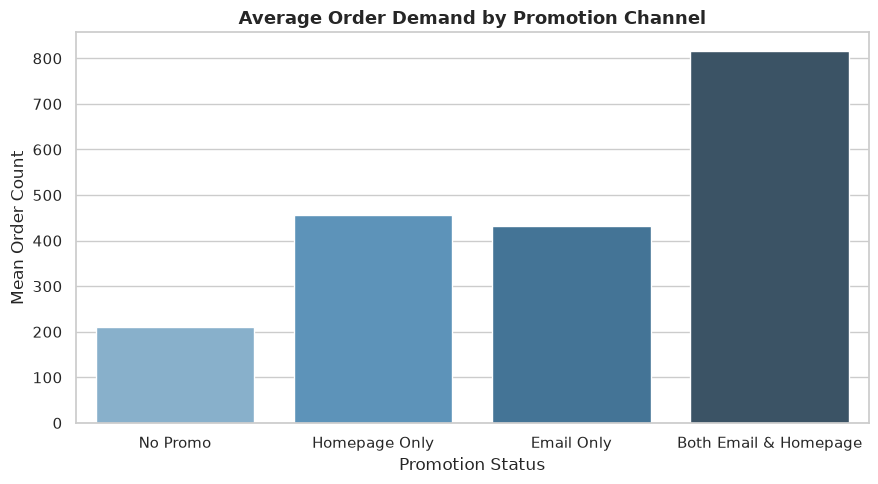

,promo_type,avg_orders,median_orders,total_records
0,No Promo,211.42,122.00,388874
1,Homepage Only,455.88,258.00,30624
2,Email Only,431.28,229.00,17819
3,Both Email & Homepage,816.25,474.00,19231


In [5]:
# 5. Promotional Impact: Emailer vs Homepage Placement
# Measure how marketing promotions boost average weekly order counts.
promo_summary = df_demand.groupby(["emailer_for_promotion", "homepage_featured"]).agg(
    avg_orders=("num_orders", "mean"),
    median_orders=("num_orders", "median"),
    total_records=("id", "count")
).reset_index()

promo_summary["promo_type"] = [
    "No Promo", "Homepage Only", "Email Only", "Both Email & Homepage"
]

plt.figure(figsize=(9, 5))
sns.barplot(data=promo_summary, x="promo_type", y="avg_orders", palette="Blues_d")
plt.title("Average Order Demand by Promotion Channel", fontsize=13, fontweight="bold")
plt.xlabel("Promotion Status")
plt.ylabel("Mean Order Count")
plt.tight_layout()
plt.show()

display(promo_summary[["promo_type", "avg_orders", "median_orders", "total_records"]])


/tmp/ipykernel_26313/1676261986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_demand.values, y=cuisine_demand.index, ax=axes[0], palette="viridis")
/tmp/ipykernel_26313/1676261986.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=center_demand.index, y=center_demand.values, ax=axes[1], palette="mako")


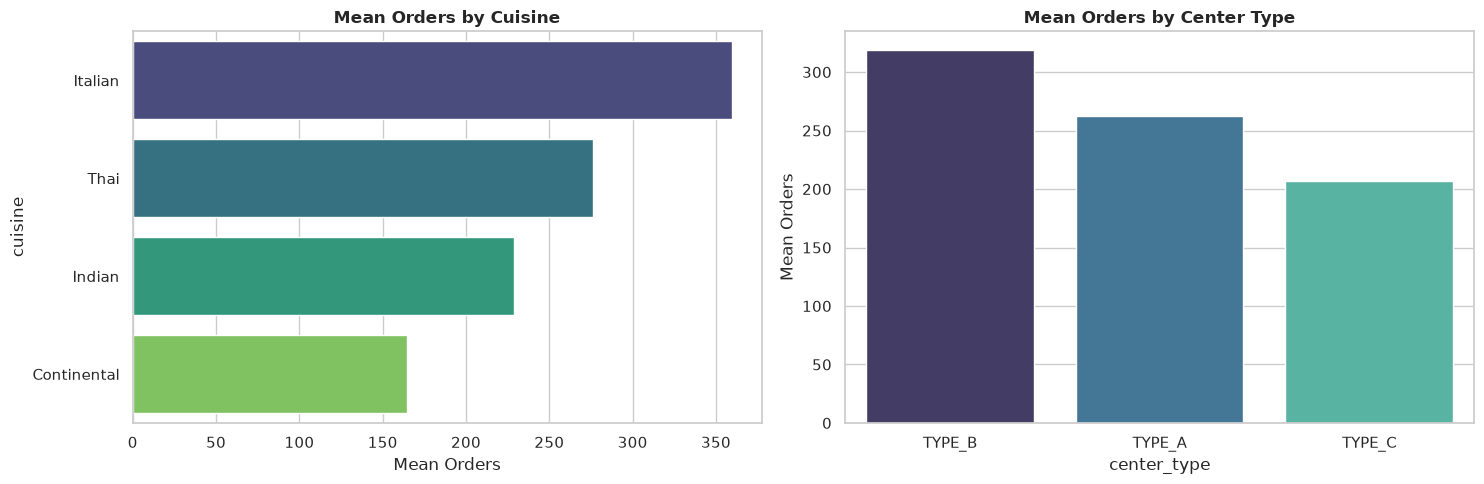

In [6]:
# 6. Demand by Cuisine and Fulfillment Center Type
# Compare popularity and demand across cuisine categories (Italian, Indian, Thai, etc.) and center types.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mean orders by cuisine
cuisine_demand = df_demand.groupby("cuisine")["num_orders"].mean().sort_values(ascending=False)
sns.barplot(x=cuisine_demand.values, y=cuisine_demand.index, ax=axes[0], palette="viridis")
axes[0].set_title("Mean Orders by Cuisine", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Mean Orders")

# Mean orders by fulfillment center type
center_demand = df_demand.groupby("center_type")["num_orders"].mean().sort_values(ascending=False)
sns.barplot(x=center_demand.index, y=center_demand.values, ax=axes[1], palette="mako")
axes[1].set_title("Mean Orders by Center Type", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean Orders")

plt.tight_layout()
plt.show()


In [7]:
# 7. Ingest real-world delivery operational logistics data
# Load food_delivery_india.csv containing distance, traffic, weather, and delivery delay metrics.
delivery_df = pd.read_csv("../data/raw/delivery/food_delivery_india.csv")
print(f"Logistics Dataset: {delivery_df.shape[0]:,} records, {delivery_df.shape[1]} columns")
delivery_df[["order_id", "delivery_distance", "order_value", "traffic_condition", "weather_condition", "delivery_delay", "customer_rating"]].head()


Logistics Dataset: 20,000 records, 31 columns


,order_id,delivery_distance,order_value,traffic_condition,weather_condition,delivery_delay,customer_rating
0,ORD000001,2.17,42.21,Medium,Snowy,17.15,4
1,ORD000002,13.40,24.82,High,Sunny,16.04,1
2,ORD000003,10.74,37.25,High,Snowy,9.09,5
3,ORD000004,6.29,49.88,High,Snowy,-2.11,4
4,ORD000005,2.94,8.53,Low,Sunny,12.20,3


/tmp/ipykernel_26313/2935982450.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=traffic_stats.index, y=traffic_stats.values, ax=axes[0], palette="Reds")
/tmp/ipykernel_26313/2935982450.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_stats.index, y=weather_stats.values, ax=axes[1], palette="Blues_r")


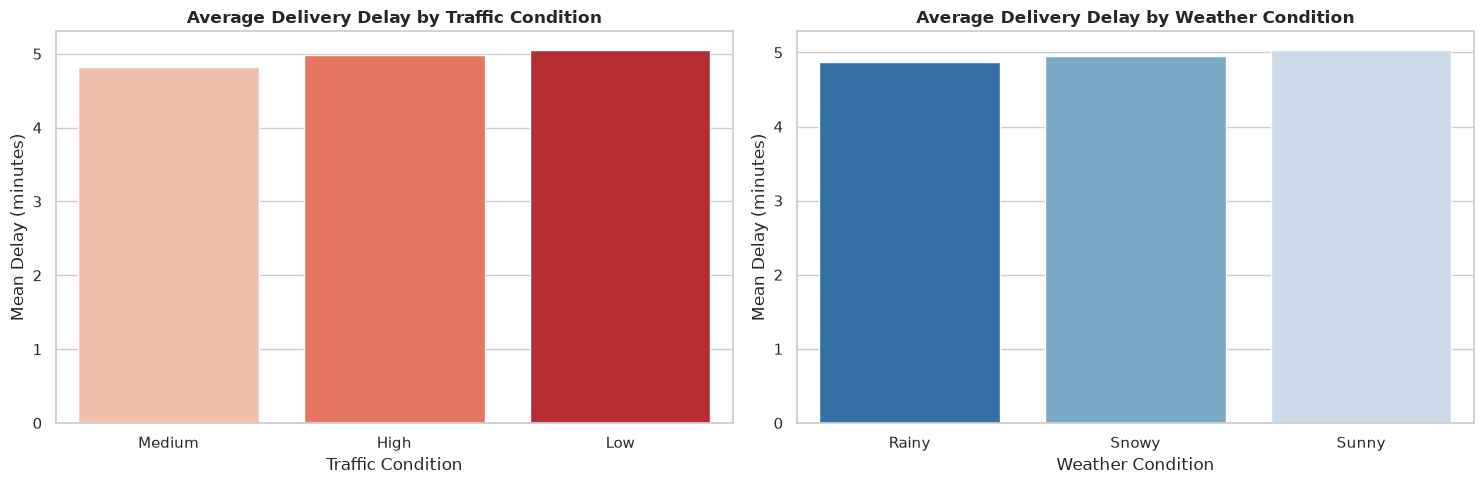

In [8]:
# 8. Impact of Traffic and Weather Conditions on Delivery Friction
# High traffic (Jam) and adverse weather (Rain/Storms) significantly increase delivery delays,
# which justifies dynamic delivery surcharges to compensate delivery partners and manage demand.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Traffic condition vs delay
traffic_stats = delivery_df.groupby("traffic_condition")["delivery_delay"].mean().sort_values()
sns.barplot(x=traffic_stats.index, y=traffic_stats.values, ax=axes[0], palette="Reds")
axes[0].set_title("Average Delivery Delay by Traffic Condition", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xlabel("Traffic Condition")

# Weather condition vs delay
weather_stats = delivery_df.groupby("weather_condition")["delivery_delay"].mean().sort_values()
sns.barplot(x=weather_stats.index, y=weather_stats.values, ax=axes[1], palette="Blues_r")
axes[1].set_title("Average Delivery Delay by Weather Condition", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xlabel("Weather Condition")

plt.tight_layout()
plt.show()
